### [1] Functions

In [1]:
import torch
torch.set_default_dtype(torch.float64)
for i in range(torch.cuda.device_count()):
    print(f'Device: {torch.cuda.get_device_properties(i).name}')
if torch.cuda.is_available():
    i = 0
    torch.cuda.set_device(i)
    device = f'cuda:{i}'
    torch.set_default_device(f'cuda:{i}')
    print(f"Cuda is available. Setting default device to: {torch.cuda.get_device_properties(i).name}")
else:
    print('Cuda is not available. Setting default device to: CPU')
    device = 'cpu'

import kan
import matplotlib.pyplot as plt
import numpy as np
import scipy
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Device: NVIDIA T400 4GB
Cuda is available. Setting default device to: NVIDIA T400 4GB


In [147]:
# --- Model Wrapper
class KanModel:
# Initialize model
    def __init__(
                 self,
                 dataset,
                 hidden_layers,
                 device,
                 **kwargs
                 ):
        n_inputs = dataset['train_input'].shape[1]
        n_outpts = dataset['train_label'].shape[1]
        width = [n_inputs] + hidden_layers + [n_outpts]

        self.model = kan.KAN(width=width, device=device, **kwargs)
        self.dataset = dataset
        self.history = {"train":[],"tests":[]}
        self.device = device
        return
# Train model
    def fit(
            self,
            dataset = None,
            **kwargs
           ):
        dataset = dataset if dataset else self.dataset
        results = self.model.fit(dataset, **kwargs)
        self.history['train'] += results['train_loss']
        self.history['tests'] += results['test_loss']
        return results
# Prune model
    def prune(
              self,
              node_th = None,
              edge_th = None,
              input_th = None,
              **kwargs
             ):
        if node_th:
            try:
                self.model = self.model.prune_node(node_th, **kwargs)
            except:
                print("Node pruning failed.")
        if edge_th:
            try:
                self.model.prune_edge(edge_th)
            except:
                print('Edge pruning failed.')
        if input_th:
            try:
                self.model = self.model.prune_input(input_th)
            except:
                print('Input pruning failed.')
        return
# Refine model
    def refine(
               self,
               num = 0,
               factor = 1
              ):
        new_grid = num if num else self.model.grid * factor 
        #print(new_grid)
        self.model = self.model.refine(new_grid)
        #print(self.model.grid)
        return
# Plot model training
    def plot_training(
                      self
                     ):
        fig, axs = plt.subplots(1,1)
        axs.plot([i for i in range(len(self.history["train"]))], self.history["train"], label='Training')
        axs.plot([i for i in range(len(self.history["tests"]))], self.history["tests"], label='Testing')
        axs.set_yscale('log'); axs.set_ylabel('Loss');axs.set_xlabel("Steps"); axs.grid(visible=True, which='both'); axs.legend(loc='upper right')
        fig.tight_layout()
        return fig
# Plot model performance
    def plot_performance(
                         self,
                         dataset = None
                        ):
        
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label']
        Y_PREDICTED = self.model(dataset['test_input']) if dataset else self.model(self.dataset['test_input'])

        Y_TRUE = Y_TRUE.detach().cpu().numpy()
        Y_PREDICTED = Y_PREDICTED.detach().cpu().numpy()

        fig, axs = plt.subplots(1,2, figsize=(12,4))

        ax=axs[0]
        ax.scatter(Y_TRUE, Y_PREDICTED, alpha=0.25, label=f"Model")
        ax.plot(np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100),np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100), color='black',ls='--', label="True")
        ax.set_xlabel("f(x)"); ax.set_ylabel("KAN(x)"); ax.legend(); ax.grid(visible=True, color='gainsboro')

        ax=axs[1]
        residuals = Y_PREDICTED[:,0] - Y_TRUE[:,0]
        pdf_fit = scipy.stats.norm.fit(residuals)
        pdf_pdf = scipy.stats.norm.pdf(np.linspace(-0.3,0.3,100), *pdf_fit)
        ax.hist(residuals, bins=100, color='cornflowerblue', density=True)
        ax.plot(np.linspace(-0.3,0.3,100), pdf_pdf, label=f'Fit: {[round(i,3) for i in pdf_fit]}')
        ax.set_xlabel("Residual"); ax.set_ylabel("Relative Frequency"); ax.grid(visible=True, color='gainsboro', label='Raw Data'); ax.legend()

        fig.tight_layout()
        return
# Evaluate model performance
    def evaluate_performance(
                            self,
                            dataset = None
                            ):
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label'].cpu().to_numpy()
        Y_PREDICTED = self.model(dataset['test_input']) if dataset else self.model(self.dataset['test_input']).detach().cpu().to_numpy()
        r2 = r2_score(Y_TRUE, Y_PREDICTED)
        mae = mean_absolute_error(Y_TRUE, Y_PREDICTED)
        mse = mean_squared_error(Y_TRUE, Y_PREDICTED)
        rmse = root_mean_squared_error(Y_TRUE, Y_PREDICTED)
        maxerr = max_error(Y_TRUE, Y_PREDICTED)
        print(f"R2: {r2}\tMAE: {mae}\tMSE: {mse}\tRMSE: {rmse}\tMaxAE: {maxerr}")
        return {'R2':r2, 'MAE':mae, 'MSE':mse, 'RMSE':rmse, 'MaxAE':maxerr}
# Plot model
    def plot(
             self,
             **kwargs
            ):
        self.model.plot(**kwargs)
        return
# Fix and obtain symbolic functions
    def symbolize(
                  self,
                  library = None,
                  **kwargs
                  ):
        self.model.auto_symbolic(library)
        return kan.utils.ex_round(self.model.symbolic_formula()[0][0],4)

In [156]:
# --- Alternative Generator
def generate_dataset(
                     function,
                     n_ins,
                     n_out,
                     train_num = 1000,
                     tests_num = 1000,
                     ranges = [[-1,1]],
                     device = 'cpu',
                     random_state = 43,
                     generator = scipy.stats.uniform,
                     **kwargs
                     ):
    if len(ranges) == 1:
        ranges = [ranges[0] for i in range(n_ins)]
    # Templates
    train_inputs = torch.zeros((train_num, n_ins))
    tests_inputs = torch.zeros((tests_num, n_ins))
    # Sample from inputs
    for i in range(n_ins):
        train_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], train_num, random_state=random_state+i))
    for i in range(n_ins):
        tests_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], tests_num, random_state=random_state+n_ins+i))
    # Compute outputs
    train_output = function(train_inputs)
    tests_output = function(tests_inputs)

    # Compute means and stds
    train_inputs_mu = torch.mean(train_inputs,0)
    train_inputs_sd = torch.std(train_inputs,0)
    tests_inputs_mu = torch.mean(tests_inputs,0)
    tests_inputs_sd = torch.std(tests_inputs,0)

    train_output_mu = torch.mean(train_output,0)
    train_output_sd = torch.std(train_output,0)
    tests_output_mu = torch.mean(tests_output,0)
    tests_output_sd = torch.std(tests_output,0)
    # Normalize
    train_inputs = (train_inputs - train_inputs_mu)/train_inputs_sd
    tests_inputs = (tests_inputs - tests_inputs_mu)/tests_inputs_sd
    train_output = (train_output - train_output_mu)/train_output_sd
    tests_output = (tests_output - tests_output_mu)/tests_output_sd
    # Package
    return_dict = {
                   'train_input':train_inputs.to(device),
                   'test_input':tests_inputs.to(device),
                   'train_label':train_output.to(device),
                   'test_label':tests_output.to(device)
                   }
    stats_dict = {
                  'train_input':(train_inputs_mu.to(device), train_inputs_sd.to(device)),
                  'test_input':(tests_inputs_mu.to(device), tests_inputs_sd.to(device)),
                  'train_label':(train_output_mu.to(device), train_output_sd.to(device)),
                  'test_label':(tests_output_mu.to(device), tests_output_sd.to(device)),
                  }
    return return_dict, stats_dict


### [2] Division

In [157]:
# --- Create dataset
f = lambda x: torch.divide(x[:,[0]], x[:,[1]])
dataset, statistics = generate_dataset(f, 2, 1, 2000, 2000, device='cuda:0', ranges=[[1, 10]])
dataset2 = kan.create_dataset(f, 2, train_num=1000, test_num=1000, device='cuda:0')

In [128]:
# HypPrm for initialization: width, spline order (k=3), grid intervals (grid=8), noise_scale, base_function (silu, identity, zero)
mykan = KanModel(dataset2, [3], 'cuda:0', seed=43, k=3, grid=12)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.89e-14 | test_loss: 4.33e-02 | reg: 0.00e+00 | : 100%|█| 100/100 [00:08<00:00, 12.48


saving model version 0.12



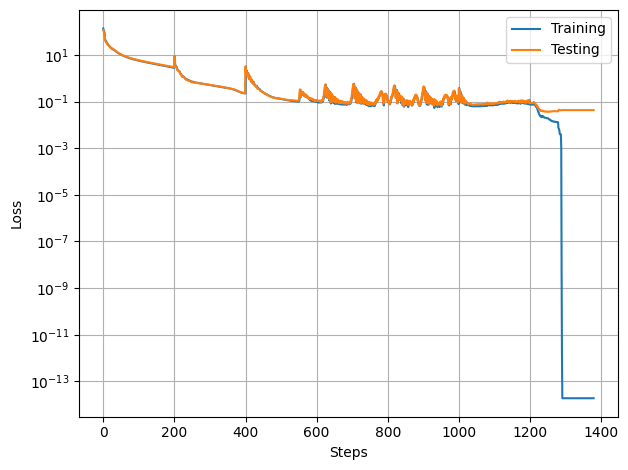

In [159]:
# HypPrm for training: opt (Adam, LBFGS), steps, lr, lamb
mykan.fit(dataset, steps=100, opt='LBFGS', lr=0.1, lamb=0.01)
mykan.plot_training()
print()

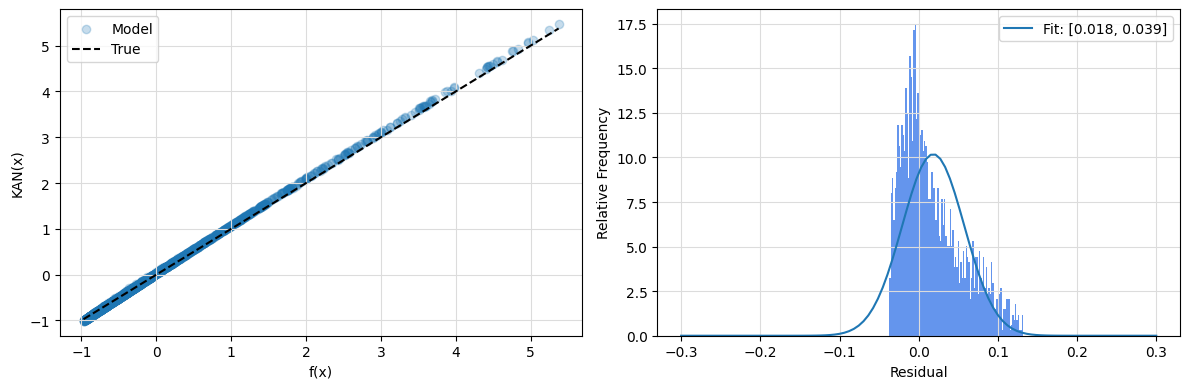

In [160]:
mykan.plot_performance(dataset)

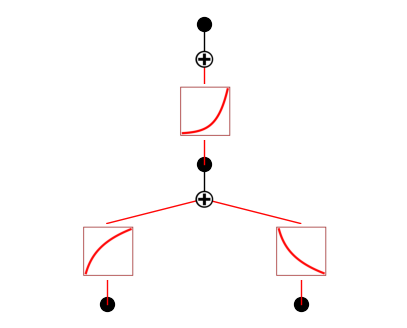

In [161]:
mykan.plot()

In [150]:
mykan.prune(node_th=0.03, edge_th=0.03)

saving model version 0.9
Edge pruning failed.


In [162]:
library = ['x','abs','1/x','exp','log']
mykan.model.auto_symbolic()
kan.utils.ex_round(mykan.model.symbolic_formula()[0][0], 4)

skipping (0,0,0) since already symbolic
skipping (0,1,0) since already symbolic
skipping (1,0,0) since already symbolic
saving model version 0.13


0.5582*(3.7192*x_1 + 8.0372)**1.0/(2.6444*x_2 + 5.6174)**1.0 - 1.1097

In [163]:
for k,v in statistics.items():
    print(f"{k}: mu={v[0]}, sd={v[1]}")

train_input: mu=tensor([5.6121, 5.5164], device='cuda:0'), sd=tensor([2.5970, 2.5968], device='cuda:0')
test_input: mu=tensor([5.4737, 5.4898], device='cuda:0'), sd=tensor([2.6106, 2.6144], device='cuda:0')
train_label: mu=tensor([1.4135], device='cuda:0'), sd=tensor([1.2738], device='cuda:0')
test_label: mu=tensor([1.4277], device='cuda:0'), sd=tensor([1.3547], device='cuda:0')


### [3] Compositions

In [213]:
# --- Create dataset
f = lambda x: torch.sqrt(torch.square(x[:,[0]] - x[:,[1]]) + torch.square(x[:,[2]] - x[:,[3]]))
dataset, statistics = generate_dataset(f, 4, 1, 2000, 2000, device='cuda:0', ranges=[[1, 10]])

In [232]:
# HypPrm for initialization: width, spline order (k=3), grid intervals (grid=8), noise_scale, base_function (silu, identity, zero)
mykan = KanModel(dataset, [5,5], 'cuda:0', seed=43, k=4, grid=8)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.80e-02 | test_loss: nan | reg: 1.38e+01 | : 100%|█| 200/200 [00:05<00:00, 38.53it/s]


saving model version 0.22



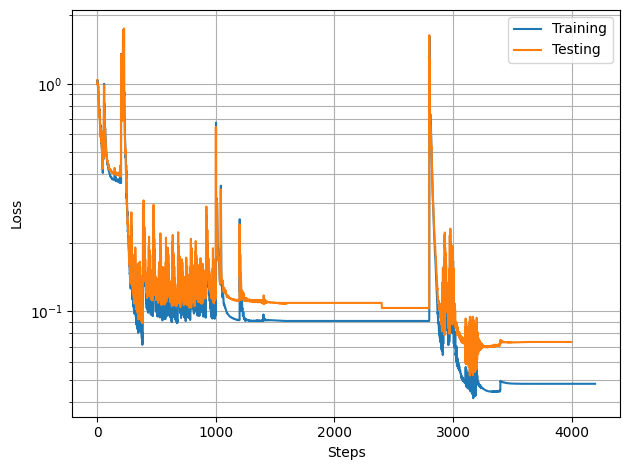

In [262]:
# HypPrm for training: opt (Adam, LBFGS), steps, lr, lamb
mykan.fit(dataset, steps=200, opt='LFBGS', lr=.0001, lamb=0.01)
mykan.plot_training()
print()

ValueError: alpha (nan) is outside 0-1 range

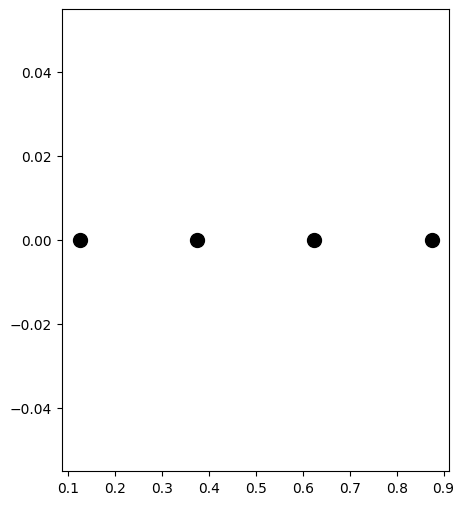

In [263]:
mykan.plot()

ValueError: The data contains non-finite values.

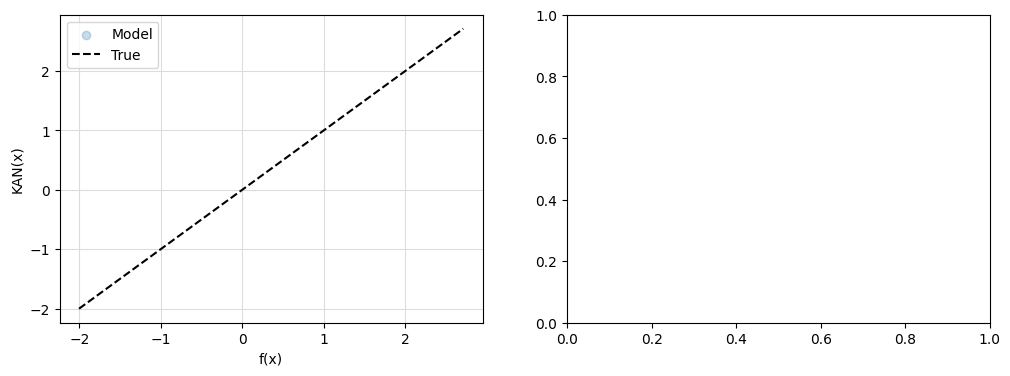

In [264]:
mykan.plot_performance(dataset)

saving model version 0.11
Edge pruning failed.


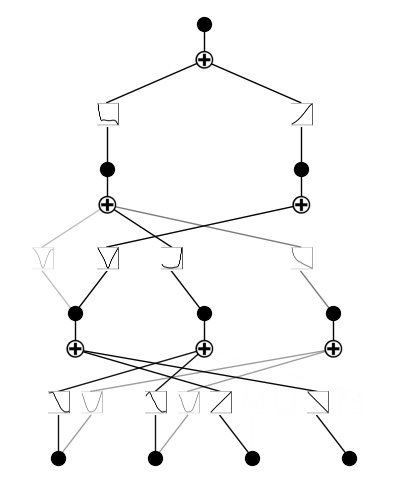

In [247]:
mykan.prune(node_th=0.03, edge_th=0.03)
mykan.plot()

In [257]:
mykan.refine(factor=2)

saving model version 0.19


In [259]:
mykan.model.auto_symbolic()
kan.utils.ex_round(mykan.model.symbolic_formula()[0][0], 4)

fixing (0,0,0) with 0, r2=0.0, c=0
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,0,2) with cos, r2=0.9995037870829162, c=2
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,1,2) with sin, r2=0.999452487752641, c=2
fixing (0,2,0) with x, r2=0.999899956869833, c=1
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (0,2,2) with 0, r2=0.0, c=0
fixing (0,3,0) with x, r2=0.9999530619631588, c=1
fixing (0,3,1) with 0, r2=0.0, c=0
fixing (0,3,2) with 0, r2=0.0, c=0
fixing (1,0,0) with 0, r2=0.0, c=0
fixing (1,0,1) with 0, r2=0.0, c=0
fixing (1,1,0) with 0, r2=0.0, c=0
fixing (1,1,1) with 0, r2=0.0, c=0
fixing (1,2,0) with x, r2=0.9633802467950263, c=1
fixing (1,2,1) with sin, r2=0.9989979848303694, c=2
fixing (2,0,0) with 0, r2=0.0, c=0
fixing (2,1,0) with 1/x, r2=0.9973725611187564, c=2
saving model version 0.21


2.1449 + 3.4738/(-0.654*sin(0.7711*sin(1.2077*x_2 - 1.581) + 0.7654*cos(1.2112*x_1 - 9.3867) - 4.9853) - 1.6959)

In [ ]:
for k,v in statistics.items():
    print(f"{k}: mu={v[0]}, sd={v[1]}")